In [2]:
#import kagglehub
#import clean_df
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

In [3]:
data = pd.read_csv("games.csv")

In [4]:
data.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [5]:
data.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


In [6]:
n_duplicated = data.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df = pd.DataFrame({
    'n_unique':data.nunique(),
    'n_missing':data.isna().sum(),
    'missing_ratio':data.isna().mean(),
    'dtype':data.dtypes.values
})

Number of duplicated rows: 0



In [7]:
display(
    df.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

,n_unique,n_missing,missing_ratio,dtype
AppID,122611,0,0.00%,int64
Name,121454,1,0.00%,object
Release date,5081,0,0.00%,object
Estimated owners,14,0,0.00%,object
Peak CCU,1110,0,0.00%,int64
Required age,15,0,0.00%,int64
Price,941,0,0.00%,float64
Discount,88,0,0.00%,int64
DLC count,117,0,0.00%,int64
About the game,113556,8449,6.89%,object


In [8]:
data2=data.drop(columns=["Movies","Screenshots","Metacritic url","Header image","AppID","Website","Score rank","Notes"])
data2['About the game'] = data2['About the game'] != ""      #).astype(int) pour quant
data2['Support email'] = data2['Support email'] != ""
data2['Support url'] = data2['Support url'] != ""
data2['Release date'] = data2['Release date'].str[-4:]

# Fonction qui va compter le nombre d'avis dans chaque ligne
def count_reviews(row):
    # S'assurer que chaque ligne est une chaîne de caractères
    if isinstance(row, str):  # Si c'est déjà une chaîne
        reviews = re.findall(r'"([^"]*)"', row)  # Recherche des avis entre guillemets
        return len(reviews)
    else:
        return 0  # Si ce n'est pas une chaîne, retourne 0

# Appliquer la fonction à la colonne 'avis'
data2['Reviews'] = data2['Reviews'].apply(count_reviews)

display(
    data2.head().style.background_gradient(cmap="BuPu")
)
# about the game et suppporturl/email:mettre en qual, changer date de sortie en année de sortie, nb de review

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Support url,Support email,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,Black Dragon Mage Playtest,2023,0 - 0,0,0,0.000000,0,0,True,[],[],0,True,True,True,False,False,0,0,0,0,0,0,0,0,0,0,nan,nan,nan,nan,nan
1,Supipara - Chapter 1 Spring Has Come!,2016,0 - 20000,0,0,5.240000,65,0,True,['English'],[],0,True,True,True,False,False,0,0,252,3,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
2,Mystery Solitaire The Black Raven,2019,0 - 20000,0,0,4.990000,0,0,True,"['English', 'French', 'German', 'Russian']",[],0,True,True,True,True,False,0,0,21,3,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
3,버튜버 파라노이아 - Vtuber Paranoia,2024,0 - 20000,1,0,8.990000,0,1,True,['Korean'],['Korean'],0,True,True,True,False,False,0,0,0,0,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",nan
4,Maze Quest VR,2025,0 - 20000,0,0,4.990000,0,0,True,['English'],['English'],0,True,True,True,False,False,0,0,0,0,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",nan


In [9]:
data2.loc[data2["Name"].duplicated()]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1179,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66724,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
1608,Shadow of the Tomb Raider: Definitive Edition,2018,2000000 - 5000000,582,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66725,1270,304,790,265,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Female Protagonist,Singleplay..."
2411,Last Stop,2023,0 - 20000,0,0,12.99,0,0,True,['English'],...,0,0,0,0,0,Tainted Games,Tainted Games,"Single-player,Steam Achievements,Full controll...","Action,Adventure,Indie","Action,Adventure,Puzzle,Walking Simulator,FPS,..."
3621,Shadow of the Tomb Raider: Definitive Edition,2018,0 - 20000,0,17,4.00,90,0,True,"['English', 'French', 'Italian', 'German', 'Sp...",...,66731,0,0,0,0,"Eidos-Montréal,Crystal Dynamics,Nixxes,Feral I...","Crystal Dynamics,Feral Interactive (Mac),Feral...","Single-player,Steam Achievements,Full controll...","Action,Adventure","Adventure,Action,Lara Croft,Female Protagonist..."
3934,LUNA,2020,50000 - 100000,0,0,0.74,0,0,True,"['English', 'Korean', 'Japanese', 'Simplified ...",...,287,0,0,0,0,Simple,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,F...","Adventure,Casual,Indie,RPG","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122496,FALL,2026,0 - 0,0,0,1.19,0,0,True,['English'],...,0,0,0,0,0,Wise In A Well,Wise In A Well,"Single-player,Custom Volume Controls,Mouse Onl...","Action,Casual,Indie",NaN
122530,Sycophant,2025,0 - 0,0,0,34.99,0,0,True,['Simplified Chinese'],...,0,0,0,0,0,Fractious,Fractious,"Single-player,Family Sharing","Casual,RPG",NaN
122557,Conquest,2026,0 - 0,0,0,3.99,0,0,True,['English'],...,0,0,0,0,0,Zellgert Games,Zellgert Games,"Single-player,Steam Achievements,Camera Comfor...","Adventure,Indie,RPG",NaN
122561,Space Aces,2026,0 - 0,0,0,0.00,0,0,True,['English'],...,0,0,0,0,0,DewEnforcer,Space Aces,"Multi-player,MMO,PvP,Online PvP,Co-op,Online C...","Action,Casual,Massively Multiplayer,Free To Play",NaN


In [10]:
data3 = data2.loc[data2.groupby("Name")["Peak CCU"].idxmax()]
data3.loc[data3["Name"] == "Space Aces"]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1604,Space Aces,2022,0 - 0,0,0,0.0,0,0,True,['English'],...,0,0,0,0,0,"Matthew Hubbs,Austin Brooks,Bradley Vanderzalm...",Matthew Hubbs,"Single-player,Partial Controller Support","Action,Indie,Simulation",NaN


In [11]:
qual = data3.select_dtypes(exclude='int64')
quant = data3.select_dtypes(include='int64')
display(qual.head())
display(quant.head())

,Name,Release date,Estimated owners,Price,About the game,Supported languages,Full audio languages,Support url,Support email,Windows,Mac,Linux,Developers,Publishers,Categories,Genres,Tags
43895,! Shakabula *,2023,0 - 20000,14.99,True,['English'],[],True,True,True,False,False,Skermunkel,Skermunkel,"Single-player,Full controller support,Steam Cl...","Action,Indie,RPG,Early Access","Early Access,Action,RPG,JRPG,Shooter,Bullet He..."
56348,! That Bastard Is Trying To Steal Our Gold !,2016,50000 - 100000,2.99,True,['English'],[],True,True,True,False,True,WTFOMGames,WTFOMGames,"Single-player,Steam Trading Cards,Partial Cont...","Action,Adventure,Casual,Indie","Puzzle-Platformer,Dark Humor,Dungeon Crawler,M..."
29975,! Wild Russia !,2020,0 - 20000,19.99,True,"['English', 'Simplified Chinese', 'Russian']","['English', 'Simplified Chinese', 'Russian']",True,True,True,False,False,Andreev Worlds,Andreev Worlds,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Casual","Adventure,Action,Casual,Horror,Post-apocalypti..."
121733,!AnyWay!,2018,100000 - 200000,1.79,True,"['English', 'Russian', 'French', 'Italian', 'G...",[],True,True,True,False,False,EYEFRONT,EYEFRONT,"Single-player,Multi-player,Steam Achievements,...","Adventure,Casual,Indie","Side Scroller,Precision Platformer,2D Platform..."
64033,!LABrpgUP!,2018,20000 - 50000,0.99,True,['English'],[],True,True,True,False,False,UPandQ,UPandQ,"Single-player,Family Sharing","Adventure,Casual,Indie,RPG","Adventure,Indie,Casual,RPG"


,Peak CCU,Required age,Discount,DLC count,Reviews,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks
43895,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0
56348,0,0,0,0,0,0,0,164,77,0,0,373,0,392,0
29975,0,0,0,0,0,0,0,45,32,9,0,0,0,0,0
121733,2,0,10,39,0,0,0,412,182,4997,496,344,0,374,0
64033,0,0,0,0,0,0,0,26,32,2021,0,0,0,0,0


In [12]:
#clean=clean_df.clean()

In [13]:
total_count=len(data)
print(total_count)

122611


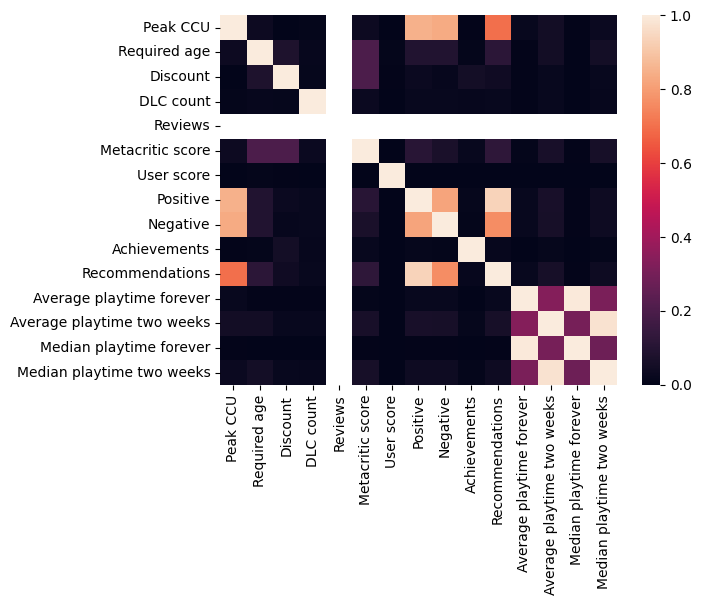

In [14]:
corr=quant.corr()
sns.heatmap(corr)
plt.show()

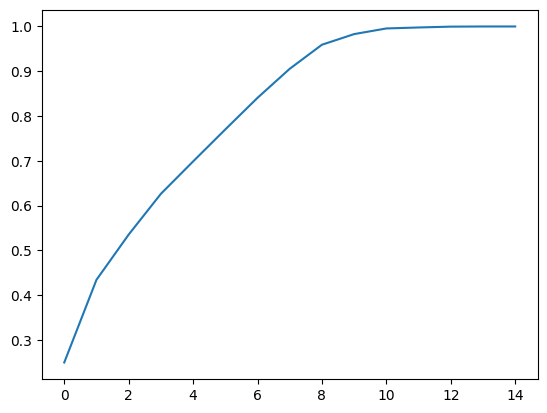

In [15]:
pca = PCA()
## Estimation, calcul des composantes principales
C = pca.fit(scale(quant)).transform(scale(quant))
## Décroissance de la variance expliquée
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()

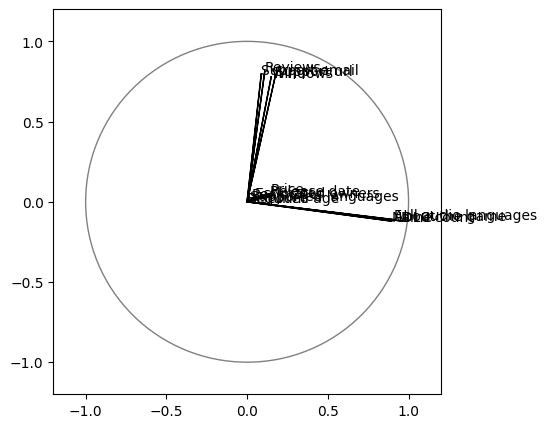

In [16]:
coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, data2.columns.values):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

In [17]:
#Est-ce qu'on clean encore plus les données (langues et autres)?

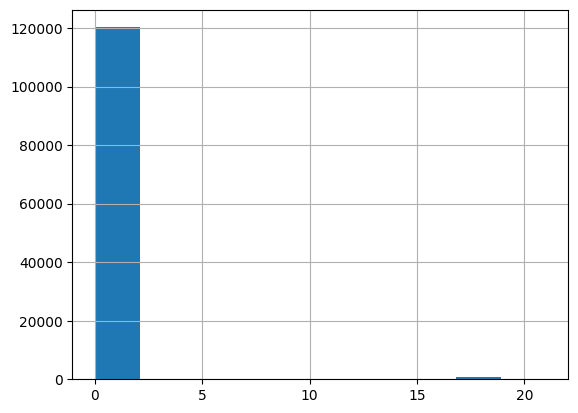

In [18]:
data3["Required age"].hist()
plt.show()

120239 1215


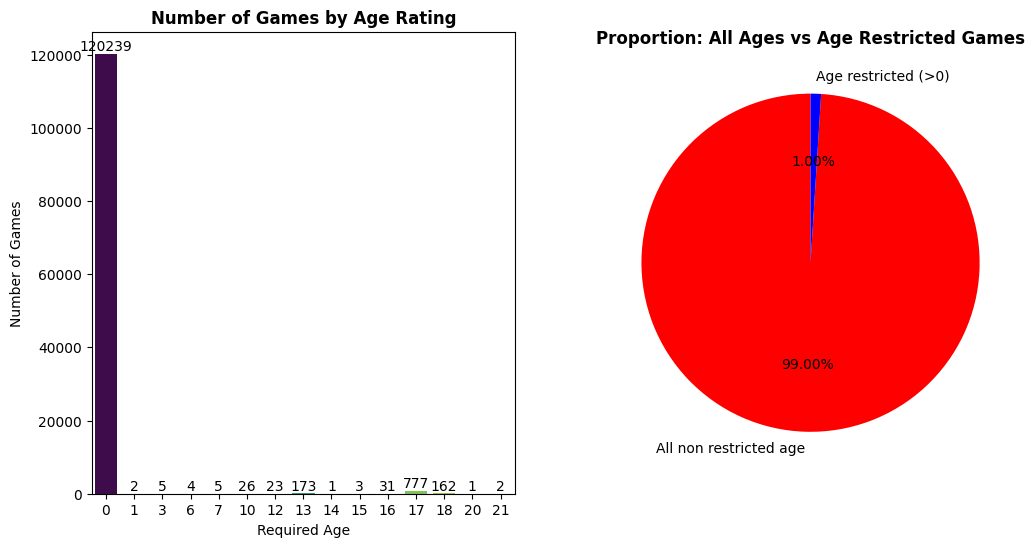

In [19]:
plt.figure(figsize=(12,6))
fig.suptitle('Age Rating Distribution Analysis', fontsize=16, fontweight='bold')

ax1=plt.subplot(1,2,1)
age_order = sorted(data3['Required age'].unique())
sns.countplot(data=data3, x='Required age', palette='viridis', order=age_order, hue=data3['Required age'], legend=False)
ax1.set_title('Number of Games by Age Rating', fontweight='bold')
ax1.set_xlabel('Required Age')
ax1.set_ylabel('Number of Games')

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom'
    )

age_0_count = (data3['Required age'] == 0).sum()
age_above_0_count = (data3['Required age'] > 0).sum()
print(age_0_count,age_above_0_count)
labels = ['All non restricted age', 'Age restricted (>0)']
sizes = [age_0_count, age_above_0_count]
colors = ['red', 'blue']

ax2=plt.subplot(1,2,2)
ax2.pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: All Ages vs Age Restricted Games', fontweight='bold')

plt.show()

=== Analysis of Game Price Distribution===
Total number of games: 121,454
Free games: 25,942 (21.4%)
Paid Games: 95,512 (78.6%)
Average price: $4.77
Median price: $2.24
Minimum price: $0.00
Maximum price: $999.98
Standard deviation: $12.57


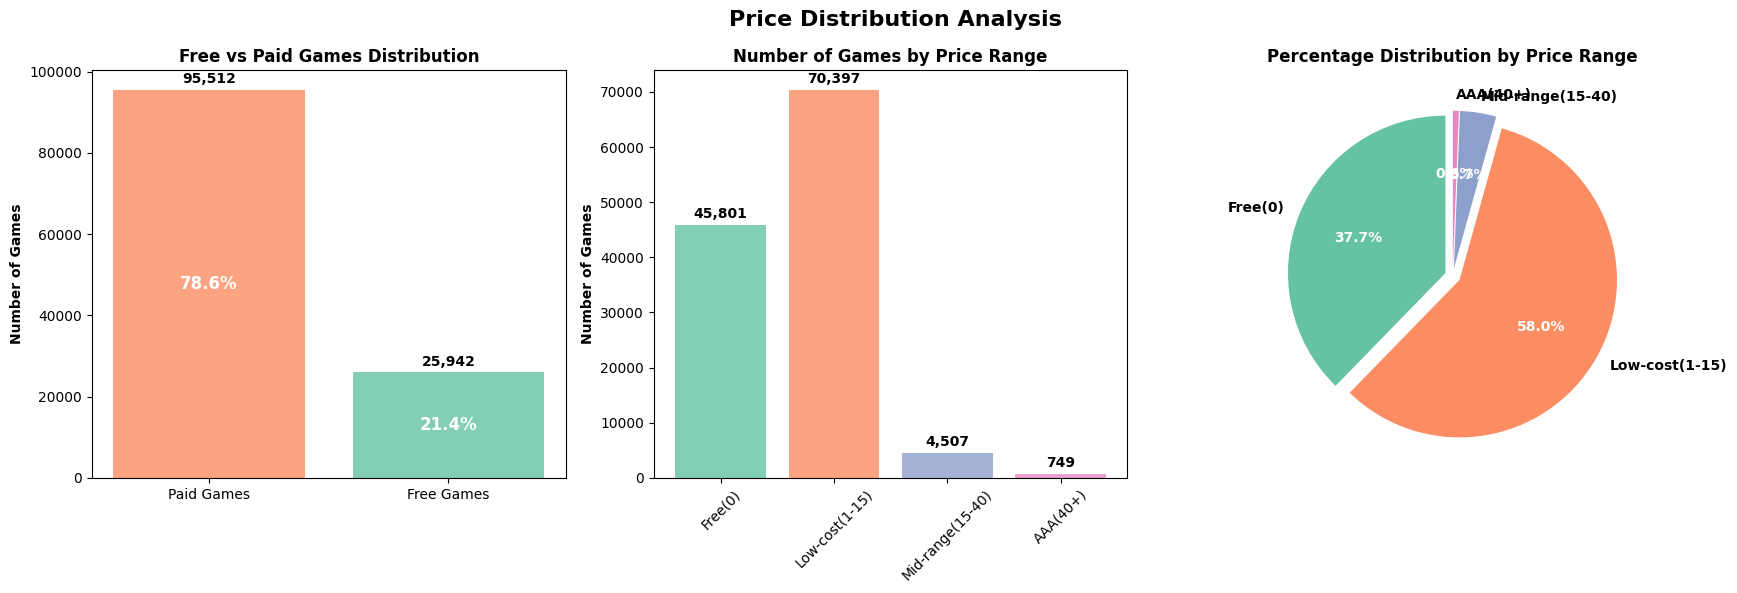

In [20]:
data3['price_category'] = data3['Price'].apply(lambda x: 'Free Games' if x == 0 else 'Paid Games')
free_count = (data3['Price'] == 0).sum()
paid_count = (data3['Price'] > 0).sum()
total_count = len(data3)
free_percentage = (free_count / total_count) * 100
paid_percentage = (paid_count / total_count) * 100
print("=== Analysis of Game Price Distribution===")
print(f"Total number of games: {total_count:,}")
print(f"Free games: {free_count:,} ({free_percentage:.1f}%)")
print(f"Paid Games: {paid_count:,} ({paid_percentage:.1f}%)")
print(f"Average price: ${data3['Price'].mean():.2f}")
print(f"Median price: ${data3['Price'].median():.2f}")
print(f"Minimum price: ${data3['Price'].min():.2f}")
print(f"Maximum price: ${data3['Price'].max():.2f}")
print(f"Standard deviation: ${data3['Price'].std():.2f}")

bins = [-1, 1, 15, 40, float('inf')]
labels = ['Free(0)', 'Low-cost(1-15)', 'Mid-range(15-40)', 'AAA(40+)']
data3['price_range'] = pd.cut(data3['Price'], bins=bins, labels=labels)
price_distribution = data3['price_range'].value_counts().sort_index()
price_percentage = data3['price_range'].value_counts(normalize=True).sort_index() * 100

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Price Distribution Analysis', fontsize=16, fontweight='bold')

colors1 = ['#fc8d62','#66c2a5']
categories = ['Paid Games', 'Free Games']
counts = [paid_count, free_count]
percentages = [paid_percentage, free_percentage]
bars1 = ax1.bar(categories, counts, color=colors1, alpha=0.8)
ax1.set_title('Free vs Paid Games Distribution', fontweight='bold')
ax1.set_ylabel('Number of Games', fontweight='bold')

for i, (bar, count, percentage) in enumerate(zip(bars1, counts, percentages)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height/2, 
             f'{percentage:.1f}%', ha='center', va='center', 
             fontweight='bold', fontsize=12, color='white')
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

colors2 = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
bars2 = ax2.bar(price_distribution.index, price_distribution.values, color=colors2, alpha=0.8)
ax2.set_title('Number of Games by Price Range', fontweight='bold')
ax2.set_ylabel('Number of Games', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)


for i, (bar, count) in enumerate(zip(bars2, price_distribution.values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(price_distribution.values)*0.01, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

explode = (0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = ax3.pie(price_percentage.values, 
                                   labels=price_percentage.index, 
                                   autopct='%1.1f%%',
                                   colors=colors2,
                                   explode=explode,
                                   startangle=90)

plt.setp(autotexts, size=10, weight="bold", color='white')
plt.setp(texts, size=10, weight="bold")
ax3.set_title('Percentage Distribution by Price Range', fontweight='bold')
ax3.axis('equal')
plt.tight_layout()
plt.show()

Sales range distribution statistics:
0 - 20000           :  74646 games |  61.5%
0 - 0               :  21438 games |  17.7%
20000 - 50000       :  11302 games |   9.3%
50000 - 100000      :   5310 games |   4.4%
100000 - 200000     :   3431 games |   2.8%
200000 - 500000     :   2840 games |   2.3%
500000 - 1000000    :   1149 games |   0.9%
1000000 - 2000000   :    720 games |   0.6%
2000000 - 5000000   :    400 games |   0.3%
5000000 - 10000000  :    124 games |   0.1%
10000000 - 20000000 :     50 games |   0.0%
20000000 - 50000000 :     31 games |   0.0%
50000000 - 100000000:      9 games |   0.0%
100000000 - 200000000:      4 games |   0.0%


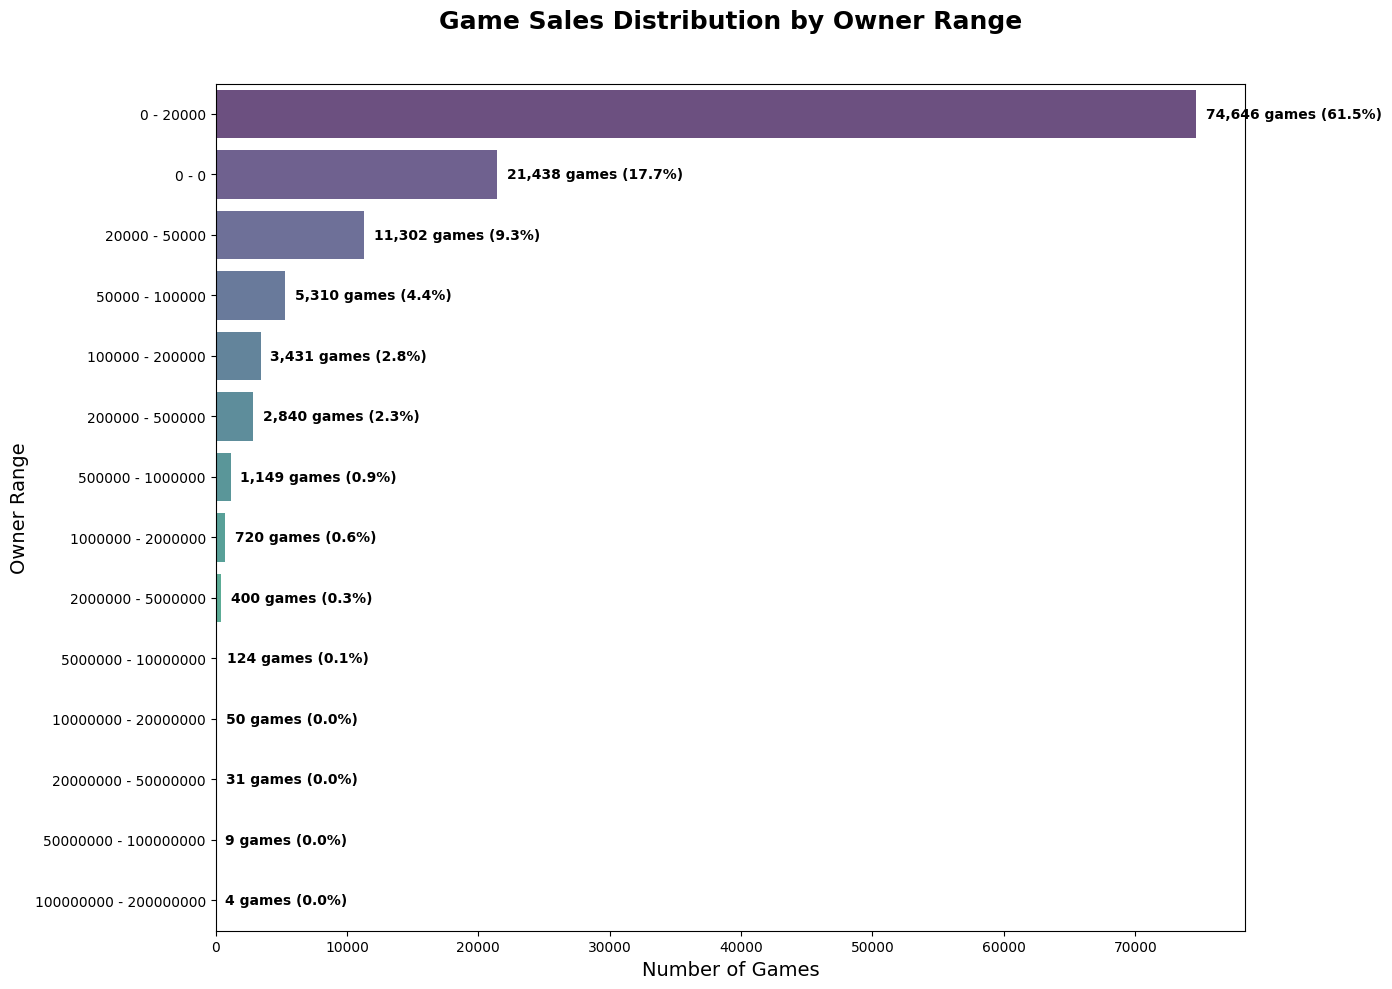

In [21]:
owner_distribution = data3['Estimated owners'].value_counts()
owner_percentage = data3['Estimated owners'].value_counts(normalize=True) * 100
owner_distribution_sorted = owner_distribution.sort_values(ascending=False)
owner_percentage_sorted = owner_percentage[owner_distribution_sorted.index]
print("Sales range distribution statistics:")
for owner_range, count in owner_distribution_sorted.items():
    percentage = owner_percentage[owner_range]
    print(f"{owner_range:20}: {count:>6} games | {percentage:>5.1f}%")

plt.figure(figsize=(14, 10))
colors = sns.color_palette("viridis", len(owner_distribution_sorted))

barplot = sns.barplot(x=owner_distribution_sorted.values, 
                     y=owner_distribution_sorted.index,
                     palette=colors, alpha=0.8,hue=owner_distribution_sorted.index,legend=False)

plt.title('Game Sales Distribution by Owner Range\n', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Games', fontsize=14)
plt.ylabel('Owner Range', fontsize=14)

for i, (count, owner_range) in enumerate(zip(owner_distribution_sorted.values, owner_distribution_sorted.index)):
    percentage = owner_percentage[owner_range]
    plt.text(count + max(owner_distribution_sorted.values)*0.01, i, 
             f'{count:,} games ({percentage:.1f}%)', 
             ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

=== Achievement Count Basic Statistics ===
Total games: 121,454
Games without achievements: 58,943
Games with achievements: 62,511

Achievement count descriptive stats:
count    121454.000000
mean         18.098959
std         141.926105
min           0.000000
25%           0.000000
50%           2.000000
75%          19.000000
max        9821.000000
Name: Achievements, dtype: float64


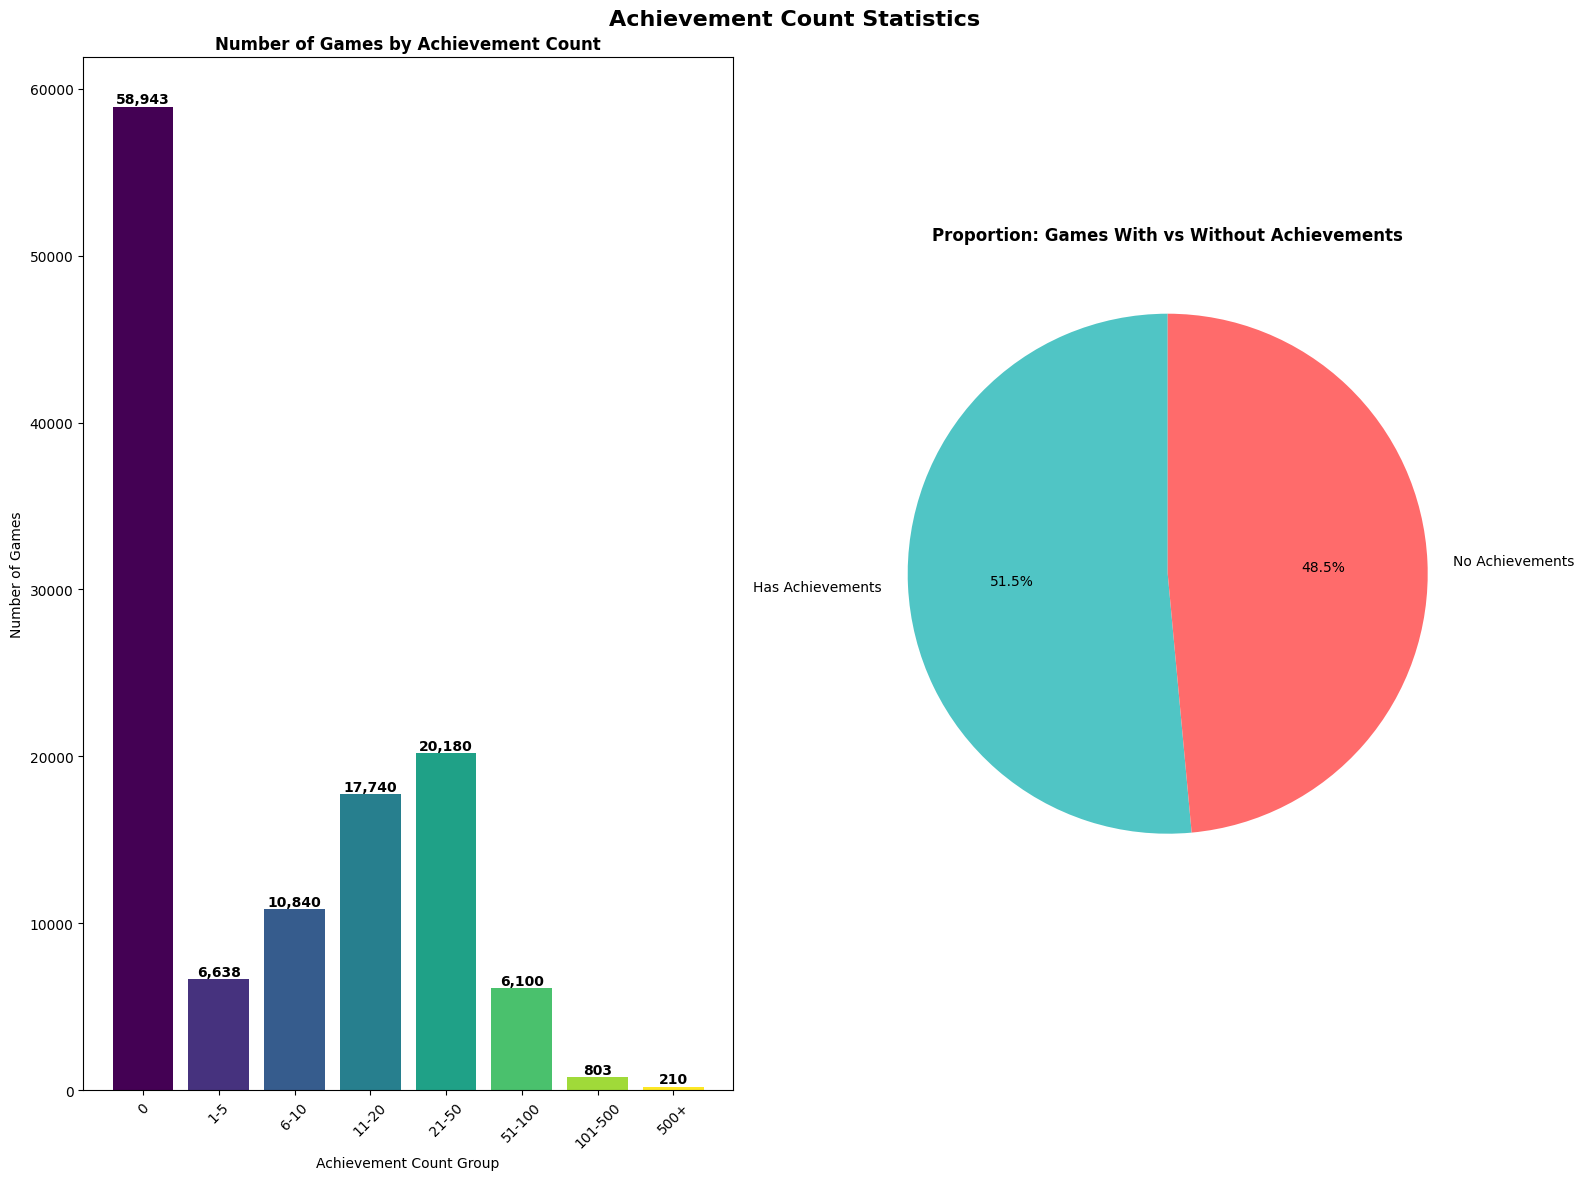


=== Average Values by Achievement Group ===
                   Price  Metacritic score  Recommendations  Positive  \
achievement_group                                                       
0                    NaN               NaN              NaN       NaN   
1-5                 3.90              0.29           898.53   1326.48   
6-10                6.36              0.78           129.76    161.35   
11-20               4.16              2.78           489.76    571.28   
21-50               5.87              6.32          1850.37   1901.56   
51-100              5.79              7.82          4833.84   5178.12   
101-500             6.02             13.96         16101.09  18977.32   
500+                1.80              2.92          8965.25  14330.56   

                   Average playtime forever  
achievement_group                            
0                                       NaN  
1-5                                   45.00  
6-10                                  93

In [22]:
print("=== Achievement Count Basic Statistics ===")
print(f"Total games: {len(data3):,}")
print(f"Games without achievements: {(data3['Achievements'] == 0).sum():,}")
print(f"Games with achievements: {(data3['Achievements'] > 0).sum():,}")

print("\nAchievement count descriptive stats:")
print(data3['Achievements'].describe())

data3['achievement_group'] = pd.cut(
    data3['Achievements'],
    bins=[-1, 0, 5, 10, 20, 50, 100, 500, 10000],
    labels=['0', '1-5', '6-10', '11-20', '21-50', '51-100', '101-500', '500+']
)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 12))
fig.suptitle('Achievement Count Statistics', fontsize=16, fontweight='bold')

group_order = ['0', '1-5', '6-10', '11-20', '21-50', '51-100', '101-500', '500+']
group_counts = data3['achievement_group'].value_counts().reindex(group_order)

bars = ax1.bar(group_order, group_counts, color=plt.cm.viridis(np.linspace(0, 1, len(group_order))))
ax1.set_title('Number of Games by Achievement Count', fontweight='bold')
ax1.set_xlabel('Achievement Count Group')
ax1.set_ylabel('Number of Games')
ax1.tick_params(axis='x', rotation=45)

for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

has_achievements = (data3['Achievements'] > 0).sum()
no_achievements = (data3['Achievements'] == 0).sum()

labels = ['Has Achievements', 'No Achievements']
sizes = [has_achievements, no_achievements]
colors = ['#50c5c5', '#ff6b6b']

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: Games With vs Without Achievements', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Average Values by Achievement Group ===")
achievement_groups = data3[data3['Achievements'] > 0].groupby('achievement_group', observed=False)
group_stats = achievement_groups.agg({
    'Price': 'mean',
    'Metacritic score': 'mean',
    'Recommendations': 'mean',
    'Positive': 'mean',
    'Average playtime forever': 'mean'
}).round(2)

print(group_stats)

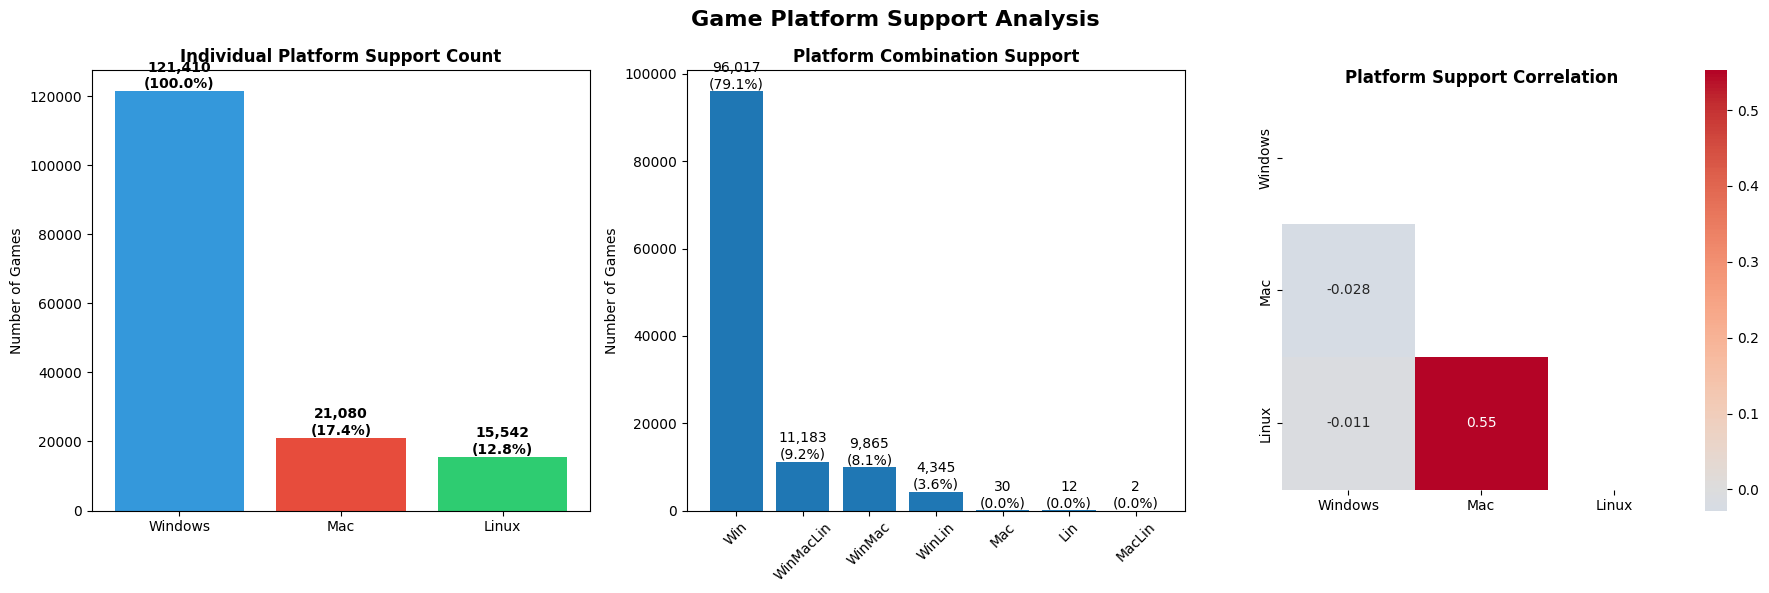

In [23]:
data3['platform_combo'] = data3.apply(lambda x: 
                               f"{'Win' if x['Windows'] else ''}"
                               f"{'Mac' if x['Mac'] else ''}"
                               f"{'Lin' if x['Linux'] else ''}", axis=1)
data3['platform_combo'] = data3['platform_combo'].replace('', 'None')

platform_combo_counts = data3['platform_combo'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Game Platform Support Analysis', fontsize=16, fontweight='bold')

platform_data = {
    'Platform': ['Windows', 'Mac', 'Linux'],
    'Count': [data3['Windows'].sum(), data3['Mac'].sum(), data3['Linux'].sum()],
    'Percentage': [data3['Windows'].mean()*100, data3['Mac'].mean()*100, data3['Linux'].mean()*100]
}

bars = axes[0].bar(platform_data['Platform'], platform_data['Count'], 
                  color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Individual Platform Support Count', fontweight='bold')
axes[0].set_ylabel('Number of Games')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{platform_data["Count"][i]:,}\n({platform_data["Percentage"][i]:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

combo_df = pd.DataFrame({
    'Combination': platform_combo_counts.index,
    'Count': platform_combo_counts.values
})
combo_df = combo_df.sort_values('Count', ascending=False)

bars = axes[1].bar(combo_df['Combination'], combo_df['Count'])
axes[1].set_title('Platform Combination Support', fontweight='bold')
axes[1].set_ylabel('Number of Games')
axes[1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / len(data3)) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 20,
                f'{height:,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=10)

platform_corr = data3[['Windows', 'Mac', 'Linux']].corr()
mask = np.triu(np.ones_like(platform_corr, dtype=bool))
sns.heatmap(platform_corr, annot=True, cmap='coolwarm', center=0, 
           square=True, mask=mask, ax=axes[2])
axes[2].set_title('Platform Support Correlation', fontweight='bold')

plt.tight_layout()
plt.show()

Total number of games: 121454
Number of games with Metacritic scores: 4177
Percentage of games with scores: 3.44%

Metacritic Score Statistics:
count    4177.000000
mean       73.857553
std        10.260475
min         6.000000
25%        68.000000
50%        75.000000
75%        81.000000
max        97.000000
Name: Metacritic score, dtype: float64


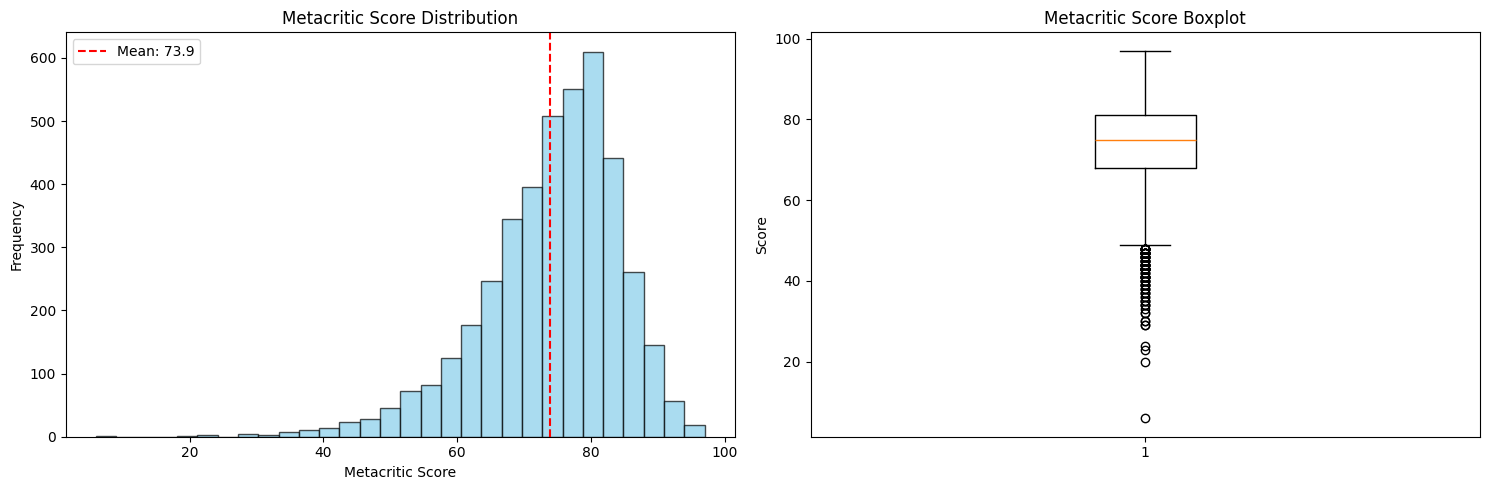

Score Category Distribution:
score_category
Excellent (90-100)     115
Fair (60-69)           805
Good (70-79)          1630
Great (80-89)         1244
Poor (0-59)            383
Name: count, dtype: int64


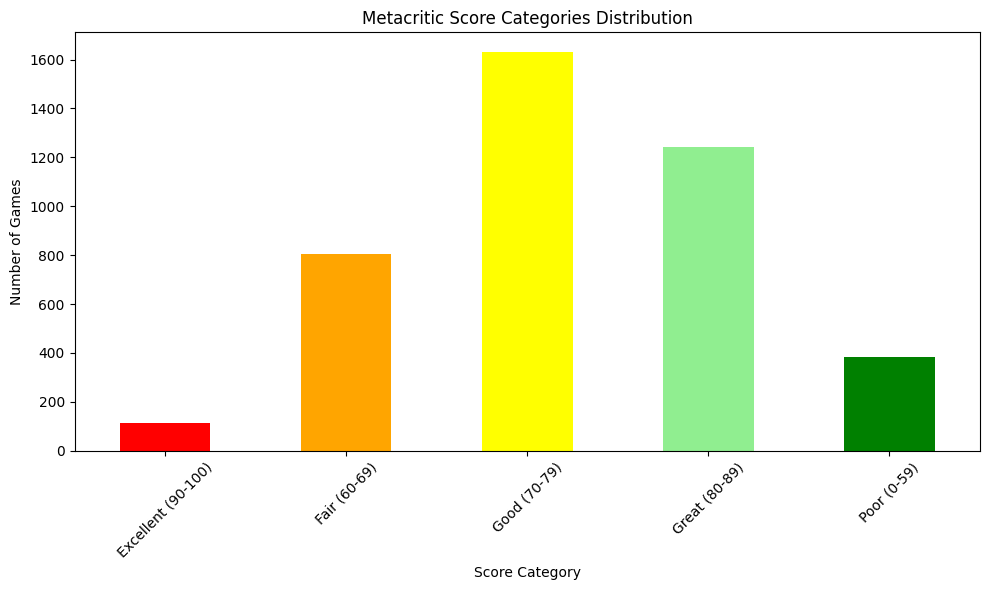

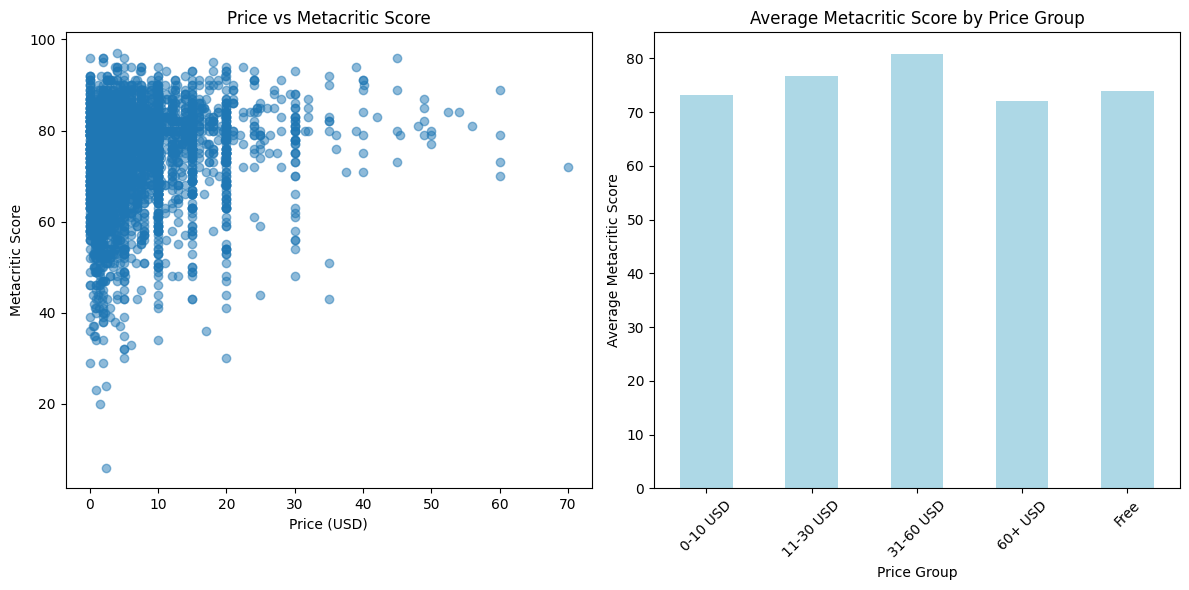


Average Scores by Price Range:
              mean  count    std
price_group                     
0-10 USD     73.15   3236  10.17
11-30 USD    76.77    665   9.85
31-60 USD    80.81     47   9.46
60+ USD      72.00      1    NaN
Free         73.91    228  10.85
Average Metacritic Scores by Game Genre:
Empty DataFrame
Columns: [mean_score, game_count, std_score]
Index: []


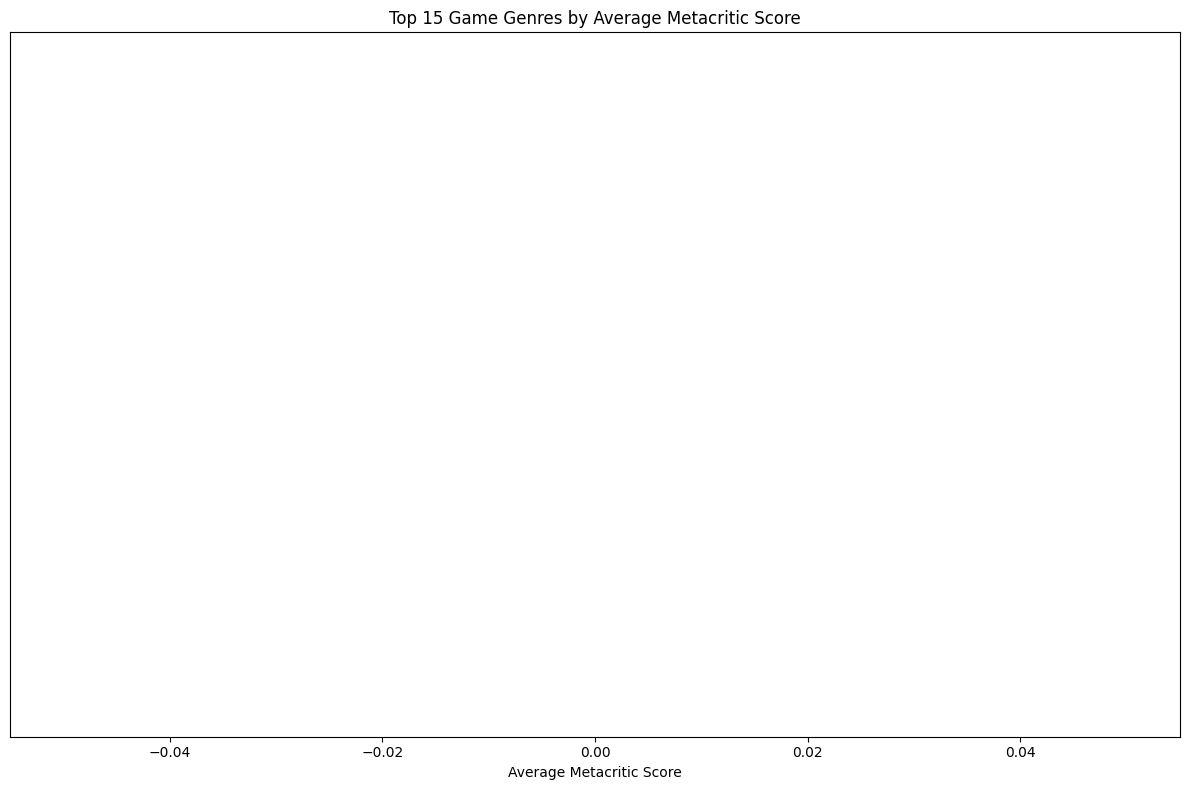

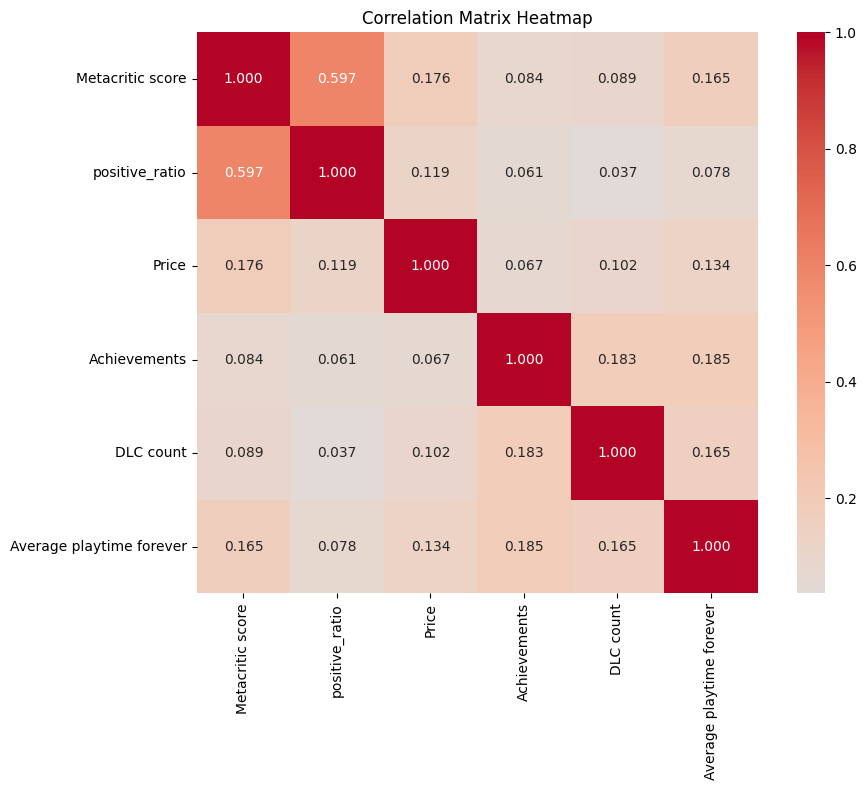

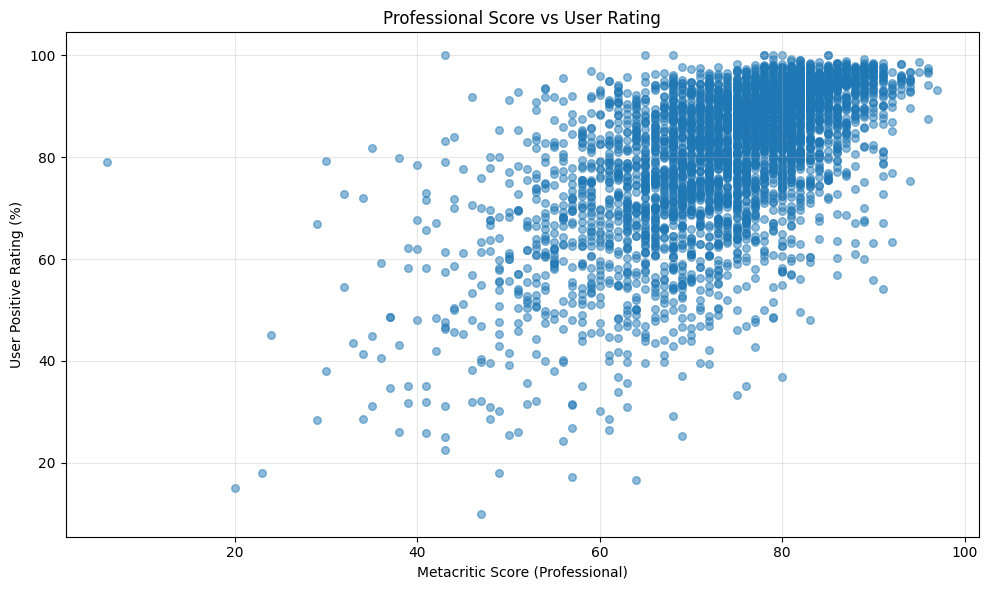

Successfully parsed dates: 4177/4177
Date parsing success rate: 100.00%


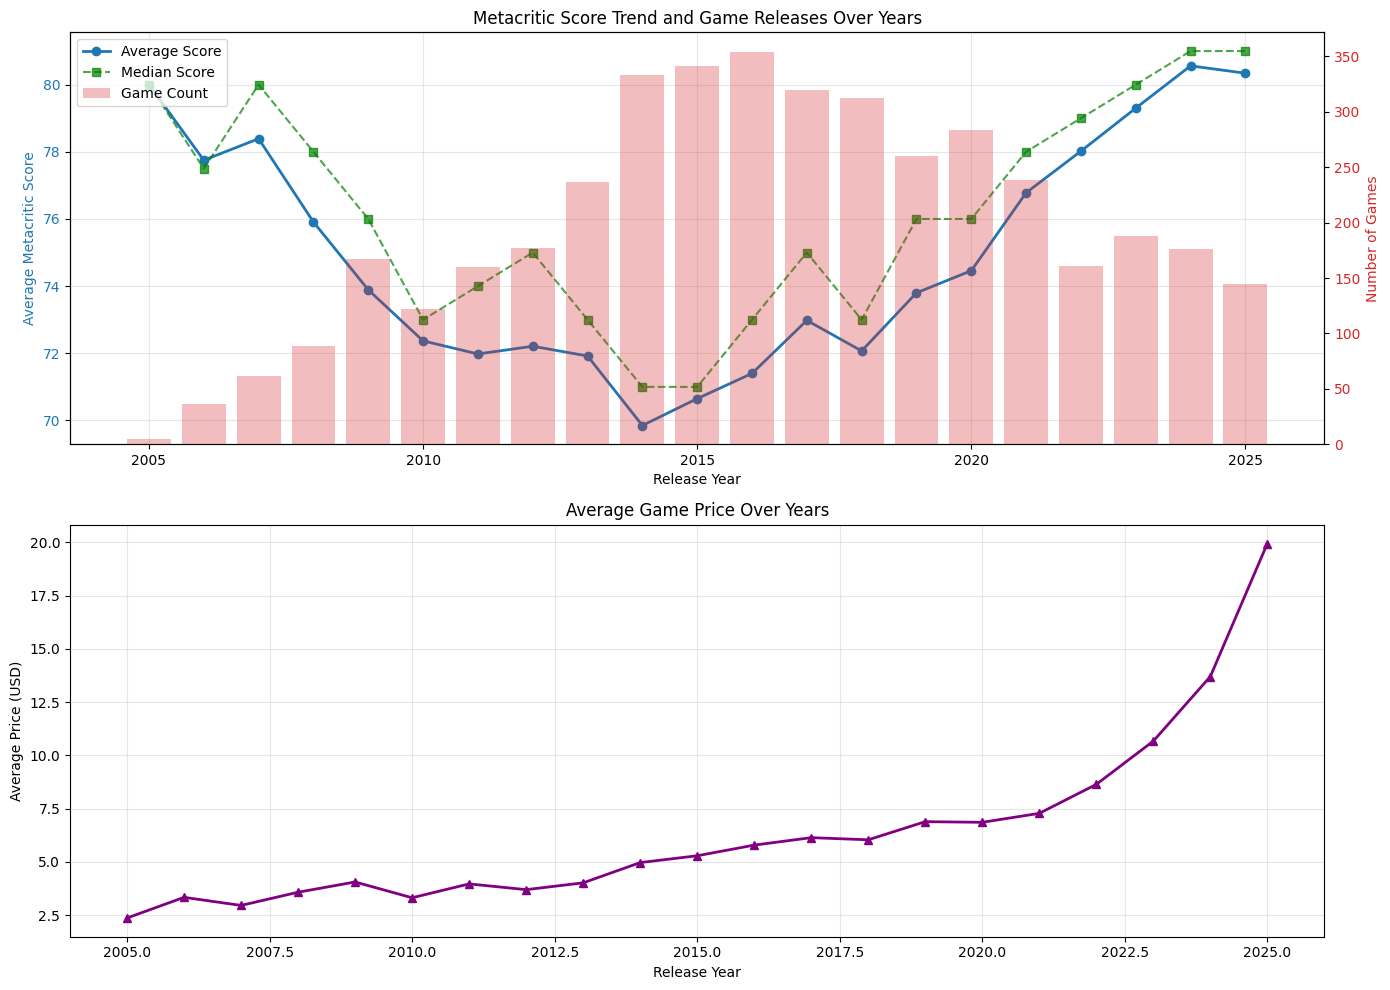


3. Top games:
   Highest Rated Games:
   - Disco Elysium - The Final Cut: 97 points (RPG)
   - Baldur's Gate 3: 96 points (Adventure,RPG,Strategy)
   - BioShock™: 96 points (Action,RPG)
   - Grand Theft Auto V Legacy: 96 points (Action,Adventure)
   - Half-Life: 96 points (Action)


In [24]:
# Filter out data with metacritic_score of 0 (indicating no rating)
df_metacritic = data3[data3['Metacritic score'] > 0].copy()

print(f"Total number of games: {len(data3)}")
print(f"Number of games with Metacritic scores: {len(df_metacritic)}")
print(f"Percentage of games with scores: {len(df_metacritic)/len(data3)*100:.2f}%")

# Basic statistics of Metacritic scores
print("\nMetacritic Score Statistics:")
print(df_metacritic['Metacritic score'].describe())

# Score distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_metacritic['Metacritic score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Metacritic Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Metacritic Score Distribution')
axes[0].axvline(df_metacritic['Metacritic score'].mean(), color='red', linestyle='--', label=f'Mean: {df_metacritic["Metacritic score"].mean():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_metacritic['Metacritic score'])
axes[1].set_title('Metacritic Score Boxplot')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Create score categories
def score_category(score):
    if score >= 90:
        return 'Excellent (90-100)'
    elif score >= 80:
        return 'Great (80-89)'
    elif score >= 70:
        return 'Good (70-79)'
    elif score >= 60:
        return 'Fair (60-69)'
    else:
        return 'Poor (0-59)'

df_metacritic['score_category'] = df_metacritic['Metacritic score'].apply(score_category)

# Score category distribution
score_dist = df_metacritic['score_category'].value_counts().sort_index()
print("Score Category Distribution:")
print(score_dist)

# Visualize score categories
plt.figure(figsize=(10, 6))
score_dist.plot(kind='bar', color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
plt.title('Metacritic Score Categories Distribution')
plt.xlabel('Score Category')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Price vs Score relationship
plt.figure(figsize=(12, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(df_metacritic['Price'], df_metacritic['Metacritic score'], alpha=0.5)
plt.xlabel('Price (USD)')
plt.ylabel('Metacritic Score')
plt.title('Price vs Metacritic Score')

# Price group analysis
def price_group(price):
    if price == 0:
        return 'Free'
    elif price <= 10:
        return '0-10 USD'
    elif price <= 30:
        return '11-30 USD'
    elif price <= 60:
        return '31-60 USD'
    else:
        return '60+ USD'

df_metacritic['price_group'] = df_metacritic['Price'].apply(price_group)

plt.subplot(1, 2, 2)
price_score = df_metacritic.groupby('price_group')['Metacritic score'].mean().sort_index()
price_score.plot(kind='bar', color='lightblue')
plt.title('Average Metacritic Score by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Average Metacritic Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Detailed statistics by price group
print("\nAverage Scores by Price Range:")
print(df_metacritic.groupby('price_group')['Metacritic score'].agg(['mean', 'count', 'std']).round(2))

# Process genres field (assuming string-formatted lists)
def parse_list_string(s):
    try:
        if isinstance(s, str):
            return ast.literal_eval(s)
        return s
    except:
        return []

df_metacritic['genres_list'] = df_metacritic['Genres'].apply(parse_list_string)

# Expand genres for analysis
genres_expanded = df_metacritic.explode('genres_list')

# Average scores by genre (only genres with sufficient samples)
genre_stats = genres_expanded.groupby('genres_list').agg({
    'Metacritic score': ['mean', 'count', 'std']
}).round(2)

genre_stats.columns = ['mean_score', 'game_count', 'std_score']
genre_stats = genre_stats[genre_stats['game_count'] >= 10].sort_values('mean_score', ascending=False)

print("Average Metacritic Scores by Game Genre:")
print(genre_stats.head(10))

# Visualize top 15 genres by average score
plt.figure(figsize=(12, 8))
top_genres = genre_stats.head(15)
plt.barh(range(len(top_genres)), top_genres['mean_score'])
plt.yticks(range(len(top_genres)), top_genres.index)
plt.xlabel('Average Metacritic Score')
plt.title('Top 15 Game Genres by Average Metacritic Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 1. Correlation between user ratings and professional scores
df_metacritic['total_reviews'] = df_metacritic['Positive'] + df_metacritic['Negative']
df_metacritic['positive_ratio'] = df_metacritic['Positive'] / df_metacritic['total_reviews']

# Calculate correlation coefficients
correlation_matrix = df_metacritic[['Metacritic score', 'positive_ratio', 'Price', 
                                   'Achievements', 'DLC count', 'Average playtime forever']].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# 2. Professional score vs user rating scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_metacritic['Metacritic score'], df_metacritic['positive_ratio']*100, 
            alpha=0.5, s=30)
plt.xlabel('Metacritic Score (Professional)')
plt.ylabel('User Positive Rating (%)')
plt.title('Professional Score vs User Rating')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df_metacritic['Metacritic score'], df_metacritic['positive_ratio']*100, 1)
p = np.poly1d(z)
plt.plot(df_metacritic['Metacritic score'], p(df_metacritic['Metacritic score']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

# More robust date parsing function
def parse_release_date(date_str):
    """
    Parse release dates in multiple formats
    """
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    # Try multiple date formats
    formats = [
        '%b %d, %Y',  # "Apr 13, 2015"
        '%B %d, %Y',  # "April 13, 2015"  
        '%b %Y',      # "Nov 2014"
        '%B %Y',      # "November 2014"
        '%Y-%m-%d',   # "2015-04-13"
        '%m/%d/%Y',   # "04/13/2015"
        '%d/%m/%Y',   # "13/04/2015"
        '%Y',         # "2015"
    ]
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    
    # If all formats fail, return NaT
    return pd.NaT

# Apply date parsing
df_metacritic['release_date_parsed'] = df_metacritic['Release date'].apply(parse_release_date)

# Check parsing results
date_parsed_count = df_metacritic['release_date_parsed'].notna().sum()
print(f"Successfully parsed dates: {date_parsed_count}/{len(df_metacritic)}")
print(f"Date parsing success rate: {date_parsed_count/len(df_metacritic)*100:.2f}%")

# View examples of failed date parsing (if any)
failed_dates = df_metacritic[df_metacritic['release_date_parsed'].isna()]['Release date'].unique()
if len(failed_dates) > 0:
    print(f"\nExamples of failed date formats:")
    for date in failed_dates[:5]:
        print(f"  - {date}")

# Extract year and month
df_metacritic['release_year'] = df_metacritic['release_date_parsed'].dt.year
df_metacritic['release_month'] = df_metacritic['release_date_parsed'].dt.month
df_metacritic['release_quarter'] = df_metacritic['release_date_parsed'].dt.quarter

# 1. Yearly score trend analysis
yearly_stats = df_metacritic[df_metacritic['release_year'].notna()].groupby('release_year').agg({
    'Metacritic score': ['mean', 'median', 'count'],
    'Price': 'mean',
    'Name': 'count'
}).round(2)

yearly_stats.columns = ['avg_score', 'median_score', 'scored_games', 'avg_price', 'total_games']
yearly_stats = yearly_stats[yearly_stats['total_games'] >= 5]  # Only include years with sufficient data

# Visualize yearly trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Average scores and game counts
color = 'tab:blue'
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Average Metacritic Score', color=color)
line1 = ax1.plot(yearly_stats.index, yearly_stats['avg_score'], 
                color=color, marker='o', linewidth=2, label='Average Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Add median line
ax1.plot(yearly_stats.index, yearly_stats['median_score'], 
        color='green', marker='s', linestyle='--', alpha=0.7, label='Median Score')

ax2_bar = ax1.twinx()
color = 'tab:red'
ax2_bar.set_ylabel('Number of Games', color=color)
bars = ax2_bar.bar(yearly_stats.index, yearly_stats['total_games'], 
                  alpha=0.3, color=color, label='Game Count')
ax2_bar.tick_params(axis='y', labelcolor=color)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_bar.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Metacritic Score Trend and Game Releases Over Years')

# Subplot 2: Yearly price trends
ax2.plot(yearly_stats.index, yearly_stats['avg_price'], 
        color='purple', marker='^', linewidth=2)
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Average Price (USD)')
ax2.set_title('Average Game Price Over Years')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n3. Top games:")
top_games = df_metacritic.nlargest(5, 'Metacritic score')[['Name', 'Metacritic score', 'Genres']]
print("   Highest Rated Games:")
for idx, row in top_games.iterrows():
    print(f"   - {row['Name']}: {row['Metacritic score']} points ({row['Genres']})")

In [25]:
#metacritic score/user Score/ Score rank?


Playtime distribution:
Zero playtime: 95486 games (78.6%)
Positive playtime: 25968 games (21.4%)

=== High Playtime Games Analysis ===
High playtime games: 5191
Playtime threshold: 595 minutes (9.9 hours)
High playtime range: 596 - 3429544 minutes


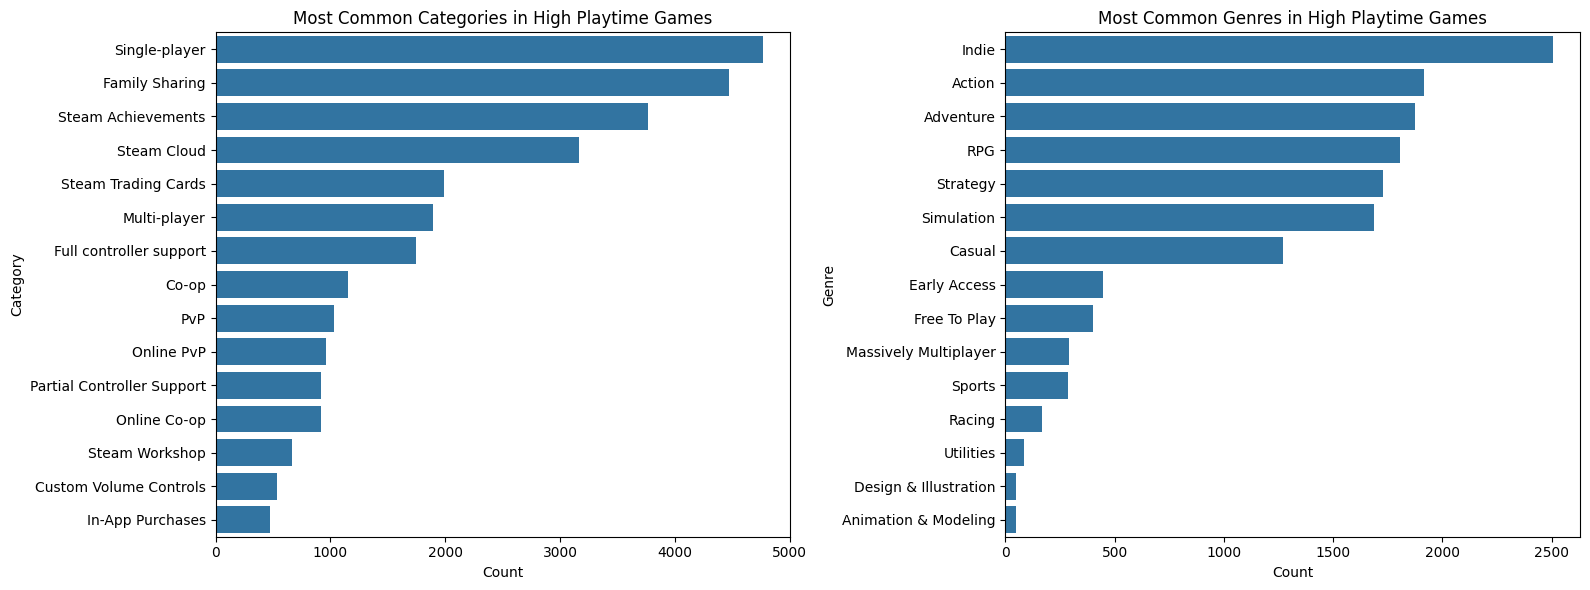

Insufficient tag data for analysis


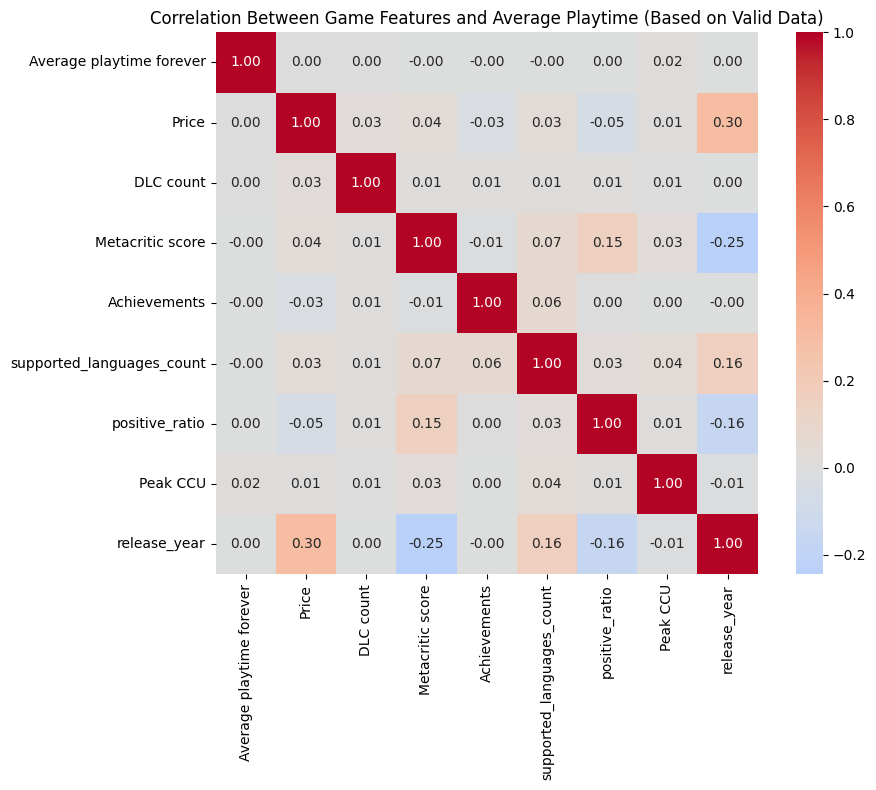

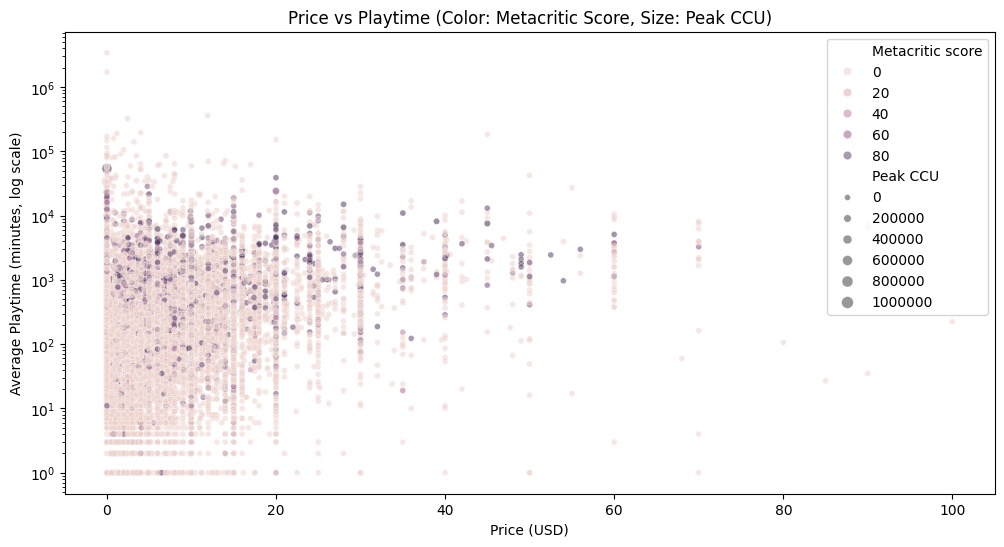

In [26]:
def preprocess_data(df):
    # Calculate basic metrics
    data3['total_votes'] = data3['Positive'] + data3['Negative']
    data3['positive_ratio'] = np.where(
        data3['total_votes'] > 0,
        data3['Positive'] / data3['total_votes'],
        0
    )
    
    # Handle stickiness metrics (avoid division by zero)
    data3['stickiness_ratio'] = np.where(
        data3['Average playtime forever'] > 0,
        data3['Average playtime two weeks'] / data3['Average playtime forever'],
        0
    )
    
    data3['retention_score'] = np.where(
        data3['Median playtime forever'] > 0,
        data3['Median playtime two weeks'] / data3['Median playtime forever'],
        0
    )
    
    # Process dates
    data3['Release date'] = pd.to_datetime(data3['Release date'], errors='coerce', format='mixed')
    data3['release_year'] = data3['Release date'].dt.year
    
    # Process language counts
    def count_languages(lang_data):
        if isinstance(lang_data, list):
            return len(lang_data)
        elif isinstance(lang_data, str):
            try:
                if lang_data.startswith('[') and lang_data.endswith(']'):
                    lang_data = lang_data[1:-1]
                languages = [lang.strip().strip("'\"") for lang in lang_data.split(',')]
                return len([lang for lang in languages if lang])
            except:
                return 0
        else:
            return 0
    
    data3['supported_languages_count'] = data3['Supported languages'].apply(count_languages)
    data3['full_audio_languages_count'] = data3['Full audio languages'].apply(count_languages)
    
    # Fixed category and genre data processing
    def parse_list_data(list_data):
        if pd.isna(list_data):
            return []
        if isinstance(list_data, list):
            return list_data
        elif isinstance(list_data, str):
            try:
                # Handle strings like "['Action', 'Adventure']" or "["Action", "Adventure"]"
                if list_data.startswith('[') and list_data.endswith(']'):
                    # Remove brackets
                    list_data = list_data[1:-1].strip()
                    if not list_data:  # Empty list
                        return []
                    
                    # Handle quotes
                    if list_data.startswith("'") or list_data.startswith('"'):
                        # Split string considering quotes
                        import re
                        items = re.findall(r"['\"]([^'\"]*)['\"]", list_data)
                        return [item.strip() for item in items if item.strip()]
                    else:
                        # No quotes, split by comma directly
                        items = [item.strip() for item in list_data.split(',')]
                        return [item for item in items if item]
                else:
                    # If it's a comma-separated string
                    return [item.strip() for item in list_data.split(',') if item.strip()]
            except Exception:
                return []
        else:
            return []
    
    # Apply parsing functions
    data3['categories_parsed'] = data3['Categories'].apply(parse_list_data)
    data3['genres_parsed'] = data3['Genres'].apply(parse_list_data)
    
    return df

# Reapply preprocessing
data3 = preprocess_data(data3)

# Check playtime distribution
playtime_zero = len(data3[data3['Average playtime forever'] == 0])
playtime_positive = len(data3[data3['Average playtime forever'] > 0])
print(f"\nPlaytime distribution:")
print(f"Zero playtime: {playtime_zero} games ({(playtime_zero/len(data3))*100:.1f}%)")
print(f"Positive playtime: {playtime_positive} games ({(playtime_positive/len(data3))*100:.1f}%)")

# Use only valid data with positive playtime for threshold calculation
valid_playtime_data = data3[data3['Average playtime forever'] > 0].copy()

if len(valid_playtime_data) == 0:
    print("Error: No valid playtime data!")
else:
    # Define high playtime criteria - calculated only on valid data
    playtime_threshold = valid_playtime_data['Average playtime forever'].quantile(0.80)
    high_playtime = valid_playtime_data[valid_playtime_data['Average playtime forever'] > playtime_threshold].copy()

    print(f"\n=== High Playtime Games Analysis ===")
    print(f"High playtime games: {len(high_playtime)}")
    print(f"Playtime threshold: {playtime_threshold:.0f} minutes ({playtime_threshold/60:.1f} hours)")
    print(f"High playtime range: {high_playtime['Average playtime forever'].min():.0f} - {high_playtime['Average playtime forever'].max():.0f} minutes")

    # Analyze category distribution
    from collections import Counter

    def flatten_categories(series):
        all_categories = []
        for categories in series:
            if isinstance(categories, list) and len(categories) > 0:
                all_categories.extend(categories)
        return Counter(all_categories)

    # High playtime games category distribution - using fixed fields
    high_playtime_categories = flatten_categories(high_playtime['categories_parsed'])
    common_categories = pd.DataFrame(high_playtime_categories.most_common(15), 
                                    columns=['Category', 'Count'])

    # Genre distribution - using fixed fields
    high_playtime_genres = flatten_categories(high_playtime['genres_parsed'])
    common_genres = pd.DataFrame(high_playtime_genres.most_common(15), 
                                columns=['Genre', 'Count'])

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Category distribution
    if len(common_categories) > 0:
        sns.barplot(data=common_categories, y='Category', x='Count', ax=axes[0])
        axes[0].set_title('Most Common Categories in High Playtime Games')
        axes[0].set_xlabel('Count')
    else:
        axes[0].text(0.5, 0.5, 'No category data', ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Category Distribution in High Playtime Games')

    # Genre distribution
    if len(common_genres) > 0:
        sns.barplot(data=common_genres, y='Genre', x='Count', ax=axes[1])
        axes[1].set_title('Most Common Genres in High Playtime Games')
        axes[1].set_xlabel('Count')
    else:
        axes[1].text(0.5, 0.5, 'No genre data', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Genre Distribution in High Playtime Games')

    plt.tight_layout()
    plt.show()

    # Tag analysis
    def analyze_tags(tags_series):
        tag_scores = {}
        for tags in tags_series:
            if isinstance(tags, dict):
                for tag, count in tags.items():
                    if tag not in tag_scores:
                        tag_scores[tag] = []
                    tag_scores[tag].append(count)
        
        # Calculate average occurrence for each tag
        tag_avg_scores = {tag: np.mean(scores) for tag, scores in tag_scores.items() 
                         if len(scores) > 10}  # At least 10 occurrences
        return dict(sorted(tag_avg_scores.items(), key=lambda x: x[1], reverse=True)[:20])

    if len(high_playtime) > 0:
        high_playtime_tags = analyze_tags(high_playtime['Tags'])
        
        # Visualize tags
        if high_playtime_tags:
            plt.figure(figsize=(12, 8))
            tags_df = pd.DataFrame(list(high_playtime_tags.items()), columns=['Tag', 'Average_Count'])
            sns.barplot(data=tags_df, y='Tag', x='Average_Count')
            plt.title('Most Common Tags in High Playtime Games (Average Occurrence)')
            plt.tight_layout()
            plt.show()
        else:
            print("Insufficient tag data for analysis")

    # Correlation analysis - using valid data
    correlation_features = [
        'Average playtime forever', 'Price', 'DLC count', 'Metacritic score',
        'Achievements', 'supported_languages_count', 'positive_ratio',
        'Peak CCU', 'release_year'
    ]

    # Filter out missing values
    corr_data = valid_playtime_data[correlation_features].fillna(0)
    corr_matrix = corr_data.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f')
    plt.title('Correlation Between Game Features and Average Playtime (Based on Valid Data)')
    plt.tight_layout()
    plt.show()

    # Price vs playtime relationship - using valid data
    plot_data = valid_playtime_data[valid_playtime_data['Price'] < 100]
    if len(plot_data) > 0:
        plt.figure(figsize=(12, 6))
        sns.scatterplot(data=plot_data, x='Price', y='Average playtime forever', 
                        alpha=0.5, hue='Metacritic score', size='Peak CCU')
        plt.yscale('log')
        plt.title('Price vs Playtime (Color: Metacritic Score, Size: Peak CCU)')
        plt.xlabel('Price (USD)')
        plt.ylabel('Average Playtime (minutes, log scale)')
        plt.show()

===== Steam Rating Scale Standards =====
Steam Official Rating Scale:
95%-100%: Overwhelmingly Positive
90%-95%: Very Positive
80%-90%: Positive
70%-80%: Mostly Positive
40%-70%: Mixed
20%-40%: Mostly Negative
0%-20%: Negative
0%: No reviews

===== Rating Distribution in Your Dataset =====

Game Rating Distribution:
No reviews: 39,298 games (32.4%)
Overwhelmingly Positive: 19,664 games (16.2%)
Mixed: 19,077 games (15.7%)
Positive: 16,407 games (13.5%)
Mostly Positive: 11,700 games (9.6%)
Very Positive: 8,565 games (7.1%)
Mostly Negative: 3,612 games (3.0%)
Negative: 3,131 games (2.6%)


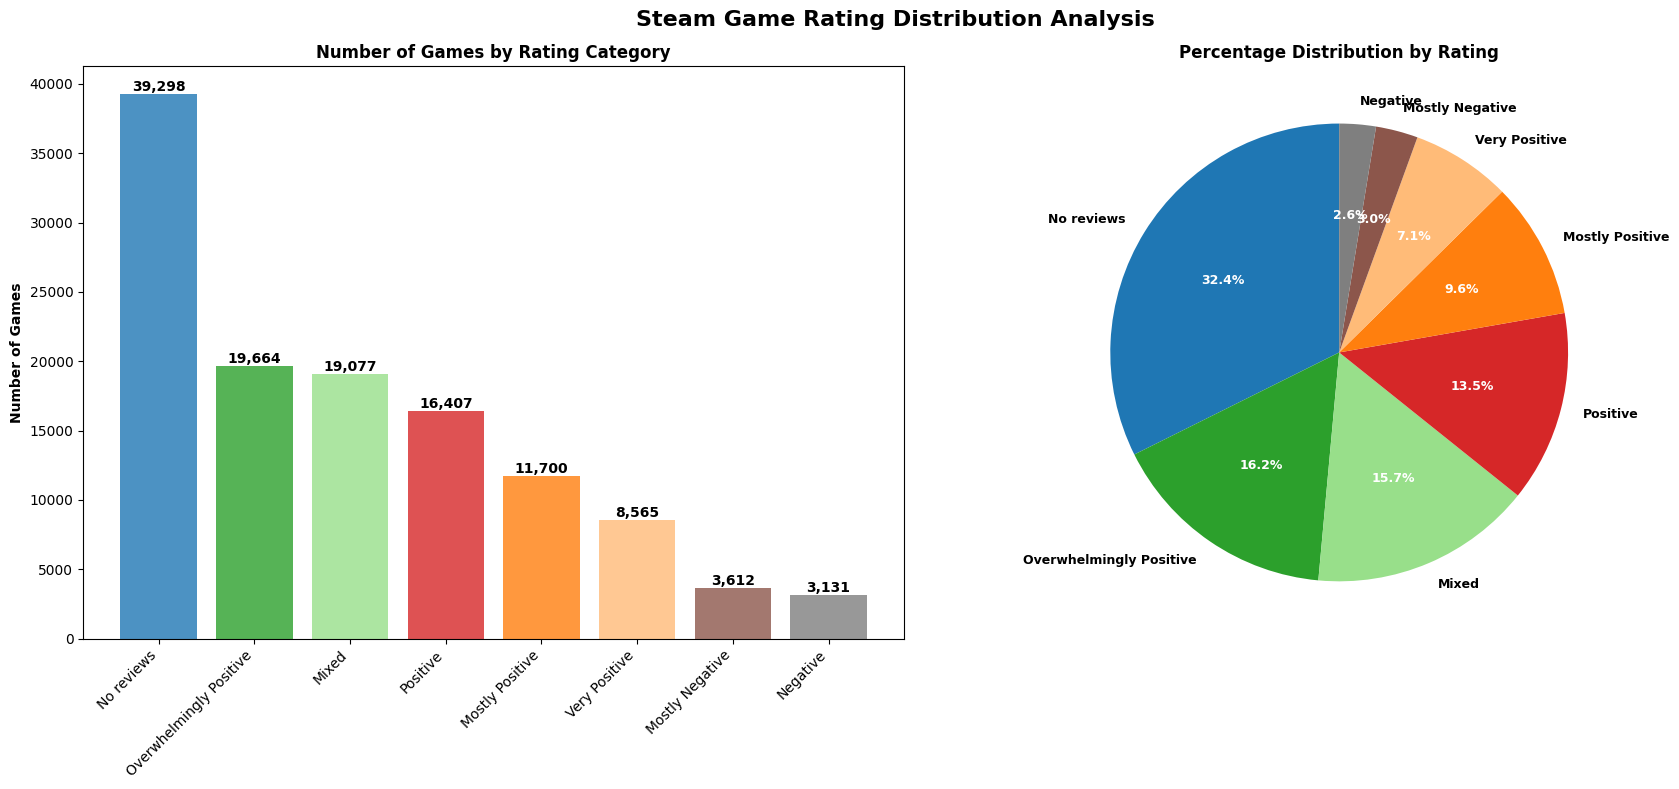


===== Detailed Analysis by Rating Category =====
Average Data by Rating Category:
                         Positive  Negative  total_votes  Price  \
steam_rating                                                      
Mixed                      466.88    300.76       767.64   4.98   
Mostly Negative             42.24     95.67       137.91   6.80   
Mostly Positive            980.50    307.30      1287.80   5.07   
Negative                     1.96     11.68        13.64   7.35   
No reviews                   0.00      0.00         0.00   3.95   
Overwhelmingly Positive   1760.27     57.61      1817.88   4.77   
Positive                  2676.60    442.26      3118.86   5.08   
Very Positive             3105.74    246.81      3352.55   5.34   

                         positive_ratio  
steam_rating                             
Mixed                              0.58  
Mostly Negative                    0.31  
Mostly Positive                    0.75  
Negative                           0

In [27]:
print("===== Steam Rating Scale Standards =====")

# Steam official rating scale (English version)
steam_rating_scale = {
    (0.95, 1.00): {"label": "Overwhelmingly Positive", "color": "#1f77b4"},
    (0.90, 0.95): {"label": "Very Positive", "color": "#2ca02c"},
    (0.80, 0.90): {"label": "Positive", "color": "#98df8a"},
    (0.70, 0.80): {"label": "Mostly Positive", "color": "#d62728"},
    (0.40, 0.70): {"label": "Mixed", "color": "#ff7f0e"},
    (0.20, 0.40): {"label": "Mostly Negative", "color": "#ffbb78"},
    (0.00, 0.20): {"label": "Negative", "color": "#8c564b"},
    (0.00, 0.00): {"label": "No reviews", "color": "#7f7f7f"}
}

print("Steam Official Rating Scale:")
print("=" * 60)
for (min_val, max_val), info in steam_rating_scale.items():
    if min_val == max_val:
        print(f"{min_val*100:.0f}%: {info['label']}")
    else:
        print(f"{min_val*100:.0f}%-{max_val*100:.0f}%: {info['label']}")

# Apply to your data
print(f"\n===== Rating Distribution in Your Dataset =====")

# Calculate positive ratio (based on SteamSpy positive and negative)
data3['positive_ratio'] = data3['Positive'] / (data3['Positive'] + data3['Negative']).replace(0, np.nan)

# Define rating classification function
def get_steam_rating(positive_ratio):
    if pd.isna(positive_ratio):
        return "No reviews"
    
    for (min_val, max_val), info in steam_rating_scale.items():
        if min_val <= positive_ratio < max_val:
            return info["label"]
    
    # Handle edge cases
    if positive_ratio >= 0.95:
        return "Overwhelmingly Positive"
    return "No reviews"

# Apply classification
data3['steam_rating'] = data3['positive_ratio'].apply(get_steam_rating)

# Count games in each rating category
rating_counts = data3['steam_rating'].value_counts()
rating_percentages = data3['steam_rating'].value_counts(normalize=True) * 100

print("\nGame Rating Distribution:")
print("=" * 40)
for rating, count in rating_counts.items():
    percentage = rating_percentages[rating]
    print(f"{rating}: {count:,} games ({percentage:.1f}%)")

# Create visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Steam Game Rating Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Rating distribution bar chart
colors = [steam_rating_scale[(0.95, 1.00)]["color"], 
          steam_rating_scale[(0.90, 0.95)]["color"],
          steam_rating_scale[(0.80, 0.90)]["color"],
          steam_rating_scale[(0.70, 0.80)]["color"],
          steam_rating_scale[(0.40, 0.70)]["color"],
          steam_rating_scale[(0.20, 0.40)]["color"],
          steam_rating_scale[(0.00, 0.20)]["color"],
          steam_rating_scale[(0.00, 0.00)]["color"]]

bars = ax1.bar(rating_counts.index, rating_counts.values, color=colors, alpha=0.8)
ax1.set_title('Number of Games by Rating Category', fontweight='bold')
ax1.set_ylabel('Number of Games', fontweight='bold')

# Set x-axis label rotation
ax1.set_xticks(range(len(rating_counts.index)))
ax1.set_xticklabels(rating_counts.index, rotation=45, ha='right')

# Add count labels
for bar, count in zip(bars, rating_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5, f'{count:,}', 
             ha='center', va='bottom', fontweight='bold')

# 2. Rating distribution pie chart
wedges, texts, autotexts = ax2.pie(rating_counts.values, labels=rating_counts.index, 
                                  autopct='%1.1f%%', colors=colors, startangle=90)
plt.setp(autotexts, size=9, weight="bold", color='white')
plt.setp(texts, size=9, weight="bold")
ax2.set_title('Percentage Distribution by Rating', fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze characteristics of each rating category
print("\n===== Detailed Analysis by Rating Category =====")

rating_stats = data3.groupby('steam_rating').agg({
    'Positive': 'mean',
    'Negative': 'mean', 
    'total_votes': 'mean',
    'Price': 'mean',
    'positive_ratio': 'mean'
}).round(2)

print("Average Data by Rating Category:")
print(rating_stats)

# Additional analysis: Relationship between vote count and rating
print(f"\n===== Relationship Between Vote Count and Rating =====")
correlation = data3['total_votes'].corr(data3['positive_ratio'])
print(f"Correlation between vote count and positive ratio: {correlation:.3f}")

# Analyze highly voted games
high_vote_games = data3[data3['total_votes'] > 1000]
if len(high_vote_games) > 0:
    print(f"\nRating Distribution of Highly Voted Games (>1000 votes):")
    high_vote_rating = high_vote_games['steam_rating'].value_counts()
    for rating, count in high_vote_rating.items():
        percentage = count / len(high_vote_games) * 100
        print(f"  {rating}: {count} games ({percentage:.1f}%)")

# Analyze zero vote games
zero_votes = data3[data3['total_votes'] == 0]
print(f"\nGames with zero votes: {len(zero_votes):,} ({len(zero_votes)/len(df)*100:.1f}%)")

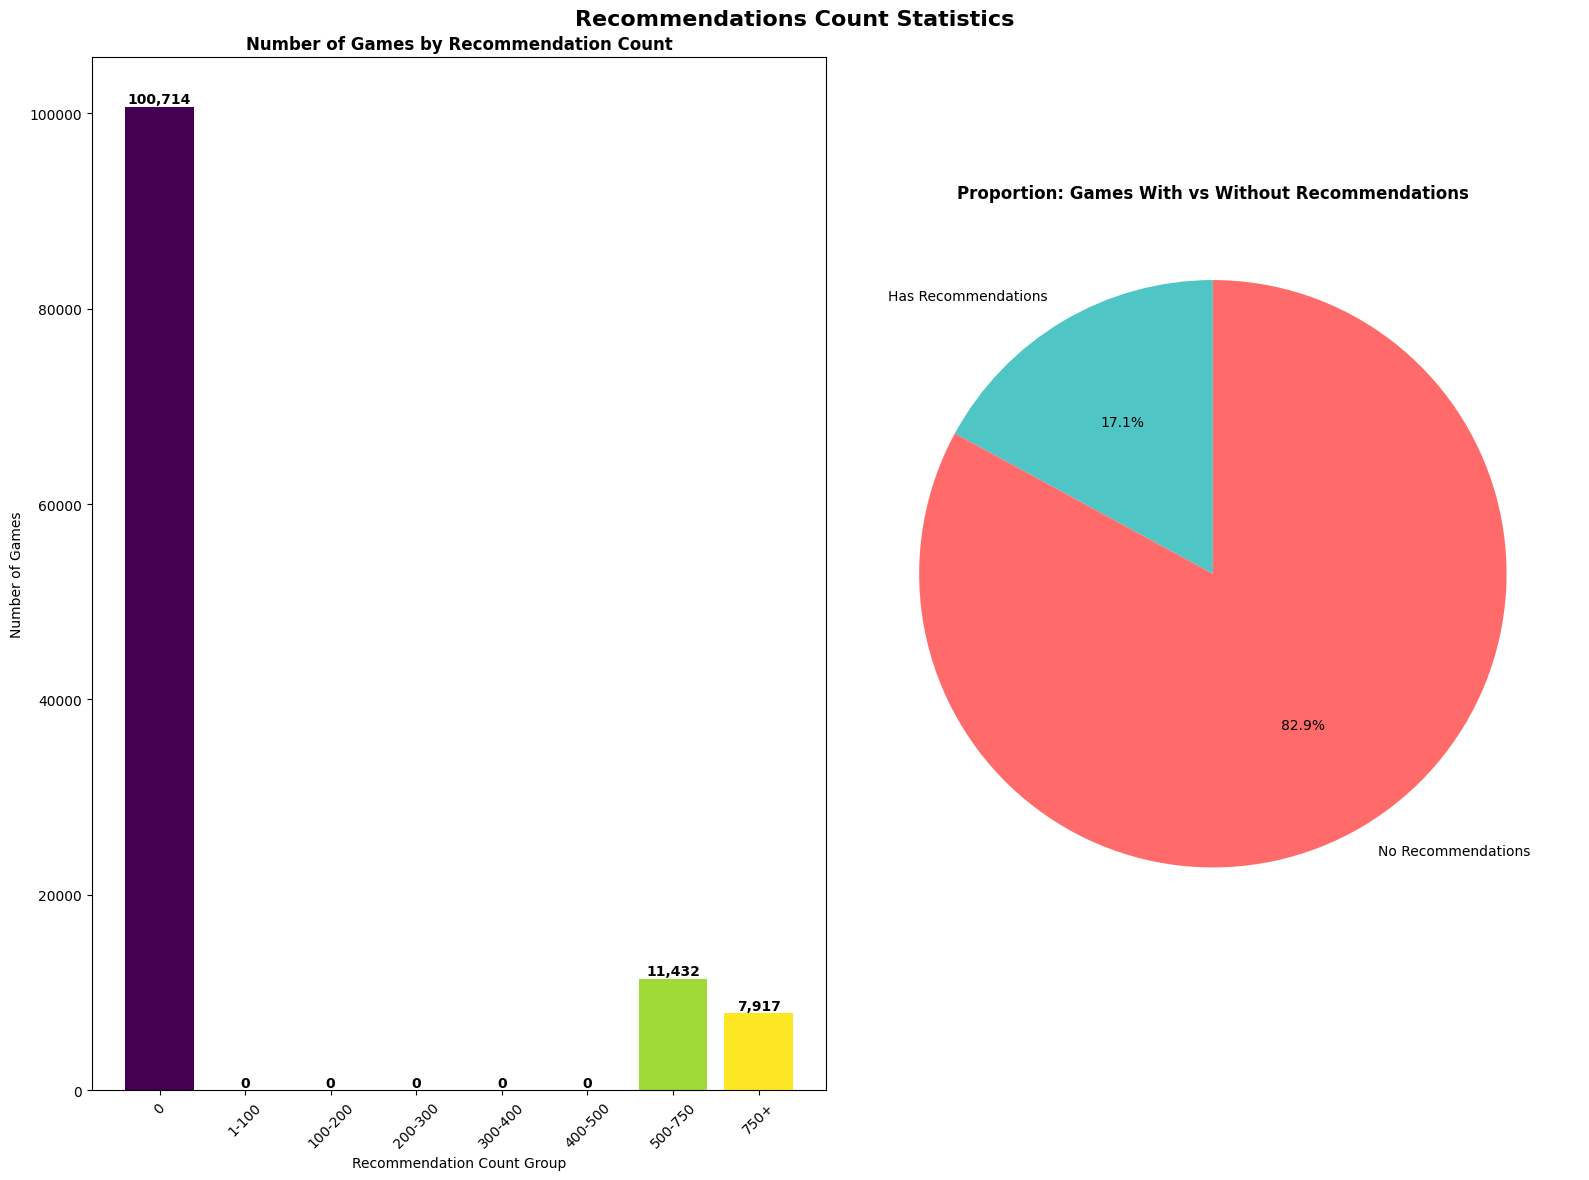

In [28]:
data3['recommendation_group'] = pd.cut(
    data3['Recommendations'],
    bins=[-1, 0, 5, 10, 20, 50, 100, 500, 10000],
    labels=['0', '1-100', '100-200', '200-300', '300-400', '400-500', '500-750', '750+']
)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 12))
fig.suptitle('Recommendations Count Statistics', fontsize=16, fontweight='bold')

group_order = ['0', '1-100', '100-200', '200-300', '300-400', '400-500', '500-750', '750+']
group_counts = data3['recommendation_group'].value_counts().reindex(group_order)

bars = ax1.bar(group_order, group_counts, color=plt.cm.viridis(np.linspace(0, 1, len(group_order))))
ax1.set_title('Number of Games by Recommendation Count', fontweight='bold')
ax1.set_xlabel('Recommendation Count Group')
ax1.set_ylabel('Number of Games')
ax1.tick_params(axis='x', rotation=45)

for bar, count in zip(bars, group_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

has_recommendations = (data3['Recommendations'] > 0).sum()
no_recommendations= (data3['Recommendations'] == 0).sum()

labels = ['Has Recommendations', 'No Recommendations']
sizes = [has_recommendations, no_recommendations]
colors = ['#50c5c5', '#ff6b6b']

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Proportion: Games With vs Without Recommendations', fontweight='bold')
plt.tight_layout()
plt.show()

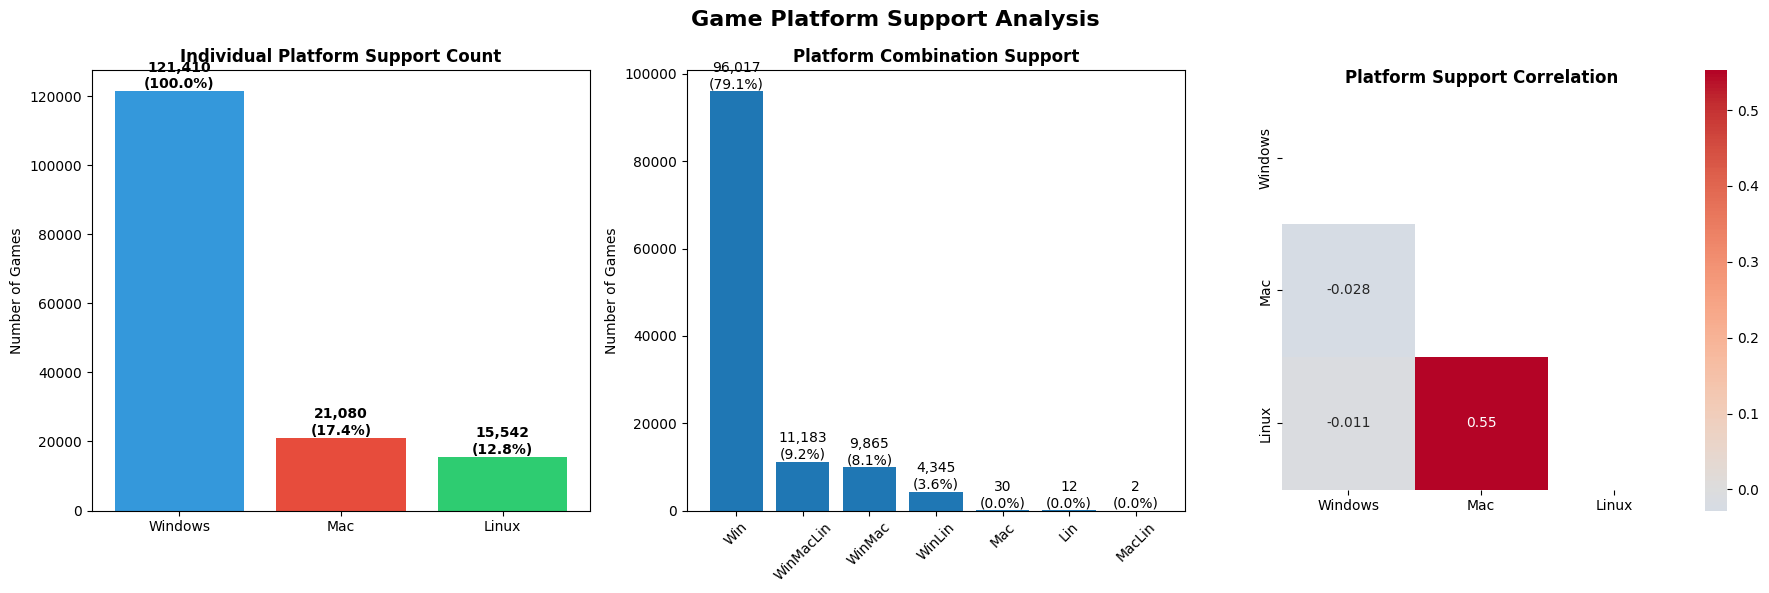

In [29]:
data3['languages_combo'] = data3.apply(lambda x: 
                               f"{'Win' if x['Windows'] else ''}"
                               f"{'Mac' if x['Mac'] else ''}"
                               f"{'Lin' if x['Linux'] else ''}", axis=1)
data3['languages_combo'] = data3['languages_combo'].replace('', 'None')

platform_combo_counts = data3['platform_combo'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Game Platform Support Analysis', fontsize=16, fontweight='bold')

platform_data = {
    'Platform': ['Windows', 'Mac', 'Linux'],
    'Count': [data3['Windows'].sum(), data3['Mac'].sum(), data3['Linux'].sum()],
    'Percentage': [data3['Windows'].mean()*100, data3['Mac'].mean()*100, data3['Linux'].mean()*100]
}

bars = axes[0].bar(platform_data['Platform'], platform_data['Count'], 
                  color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Individual Platform Support Count', fontweight='bold')
axes[0].set_ylabel('Number of Games')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{platform_data["Count"][i]:,}\n({platform_data["Percentage"][i]:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

combo_df = pd.DataFrame({
    'Combination': platform_combo_counts.index,
    'Count': platform_combo_counts.values
})
combo_df = combo_df.sort_values('Count', ascending=False)

bars = axes[1].bar(combo_df['Combination'], combo_df['Count'])
axes[1].set_title('Platform Combination Support', fontweight='bold')
axes[1].set_ylabel('Number of Games')
axes[1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / len(data3)) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 20,
                f'{height:,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=10)

platform_corr = data3[['Windows', 'Mac', 'Linux']].corr()
mask = np.triu(np.ones_like(platform_corr, dtype=bool))
sns.heatmap(platform_corr, annot=True, cmap='coolwarm', center=0, 
           square=True, mask=mask, ax=axes[2])
axes[2].set_title('Platform Support Correlation', fontweight='bold')

plt.tight_layout()
plt.show()